In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report

# Load the file using the exact name from your Google Drive
df = pd.read_csv("/content/drive/MyDrive/student_accommodation_dataset (1).csv")

# Confirm it loaded by looking at the first 5 rows
df.head()

,Listing_ID,Property_Type,Location_Zone,Capacity_Rooms,Size_SqFt,Monthly_Rent_PKR,Distance_To_Campus_KM,Selected_Amenities,User_Rating,Availability_Status,Date_Listed
0,LST-0001,Hostel,Near North Campus,3,405,9828,0.80,"Power Backup, Gym",4.5,Available,2025-02-17
1,LST-0002,Shared Apartment,Main Boulevard,4,1308,18434,2.61,"AC, Gym, Power Backup, Laundry, WiFi",4.5,Occupied,2025-03-23
2,LST-0003,Studio Flat,University Commercial Area,1,421,30094,1.13,"WiFi, Laundry, Security, Power Backup, Mess Fa...",3.4,Occupied,2025-10-02
3,LST-0004,Hostel,Satelite Town,1,155,10401,3.77,"Security, WiFi, Mess Facility",4.8,Pending Review,2026-01-31
4,LST-0005,Private Room,Near North Campus,1,179,13654,1.83,"Laundry, Mess Facility, AC",4.7,Pending Review,2025-12-26


In [3]:
df = df.dropna()
df = df[df['Availability_Status'].isin(['Available', 'Occupied'])]

le_type = LabelEncoder()
df['Property_Type_Encoded'] = le_type.fit_transform(df['Property_Type'])

le_status = LabelEncoder()
df['Target_Status'] = le_status.fit_transform(df['Availability_Status'])

X = df[['Property_Type_Encoded', 'Capacity_Rooms', 'Size_SqFt', 'Monthly_Rent_PKR', 'Distance_To_Campus_KM']]
y = df['Target_Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Data ready! Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Data ready! Training samples: 144, Testing samples: 36


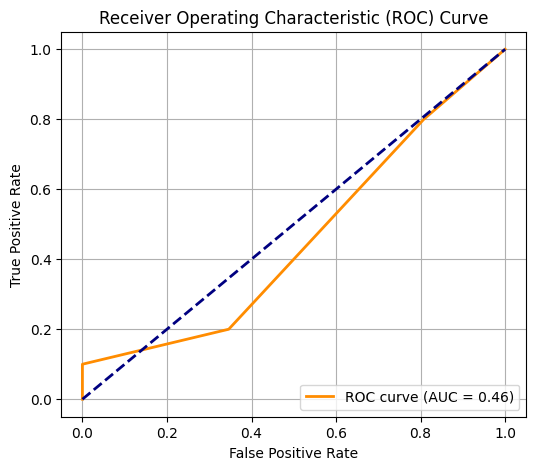

In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get prediction probabilities for the "Occupied" class (class 1)
y_probs = knn_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

# Plot the ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [4]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- MODEL EVALUATION RESULTS ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_status.classes_))

--- MODEL EVALUATION RESULTS ---
Accuracy:  75.00%
Precision: 100.00%
F1-Score:  18.18%

Detailed Classification Report:
              precision    recall  f1-score   support

   Available       0.74      1.00      0.85        26
    Occupied       1.00      0.10      0.18        10

    accuracy                           0.75        36
   macro avg       0.87      0.55      0.52        36
weighted avg       0.81      0.75      0.67        36



### Hyperparameter Tuning for k-NN

To improve the k-NN model, we can tune its hyperparameters, specifically the `n_neighbors` parameter. We will use `GridSearchCV` to search for the best number of neighbors.

In [6]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {'n_neighbors': range(1, 21)} # Test k from 1 to 20

# Create a GridSearchCV object
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_weighted')

# Fit the grid search to the scaled training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_n_neighbors = grid_search.best_params_['n_neighbors']
best_f1_score = grid_search.best_score_

print(f"Best n_neighbors: {best_n_neighbors}")
print(f"Best weighted F1-Score (cross-validation): {best_f1_score:.2%}")

Best n_neighbors: 6
Best weighted F1-Score (cross-validation): 65.47%


### Retrain Model with Best Hyperparameters and Re-evaluate

Now, let's retrain the k-NN model using the best `n_neighbors` found and evaluate its performance on the test set again.

In [7]:
# Retrain the k-NN model with the best n_neighbors
best_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
best_knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_tuned = best_knn_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted')
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

print("--- TUNED MODEL EVALUATION RESULTS ---")
print(f"Accuracy:  {accuracy_tuned:.2%}")
print(f"Precision: {precision_tuned:.2%}")
print(f"F1-Score:  {f1_tuned:.2%}")
print("\nDetailed Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=le_status.classes_))

--- TUNED MODEL EVALUATION RESULTS ---
Accuracy:  72.22%
Precision: 52.16%
F1-Score:  60.57%

Detailed Classification Report (Tuned Model):
              precision    recall  f1-score   support

   Available       0.72      1.00      0.84        26
    Occupied       0.00      0.00      0.00        10

    accuracy                           0.72        36
   macro avg       0.36      0.50      0.42        36
weighted avg       0.52      0.72      0.61        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Addressing Class Imbalance with SMOTE

The previous results clearly indicate a severe class imbalance, with the model completely failing to predict the 'Occupied' class. To mitigate this, we will use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class (`Occupied`) in the training data.

In [8]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training set shape: {Counter(y_train)}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape: {Counter(y_res)}")

Original training set shape: Counter({0: 108, 1: 36})
Resampled training set shape: Counter({0: 108, 1: 108})


### Retrain and Re-evaluate Model after SMOTE

Now that the training data is balanced, let's retrain the k-NN model using the `best_n_neighbors` found earlier and evaluate its performance on the original (unbalanced) test set.

In [9]:
# Retrain the k-NN model with the best n_neighbors on the SMOTE-resampled data
smote_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
smote_knn_model.fit(X_res, y_res)

# Make predictions on the original (unbalanced) test set
y_pred_smote = smote_knn_model.predict(X_test)

# Evaluate the SMOTE-tuned model
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote, average='weighted', zero_division=0)
f1_smote = f1_score(y_test, y_pred_smote, average='weighted', zero_division=0)

print("--- SMOTE-TUNED MODEL EVALUATION RESULTS ---")
print(f"Accuracy:  {accuracy_smote:.2%}")
print(f"Precision: {precision_smote:.2%}")
print(f"F1-Score:  {f1_smote:.2%}")
print("\nDetailed Classification Report (SMOTE-Tuned Model):")
print(classification_report(y_test, y_pred_smote, target_names=le_status.classes_, zero_division=0))

--- SMOTE-TUNED MODEL EVALUATION RESULTS ---
Accuracy:  66.67%
Precision: 66.67%
F1-Score:  66.67%

Detailed Classification Report (SMOTE-Tuned Model):
              precision    recall  f1-score   support

   Available       0.77      0.77      0.77        26
    Occupied       0.40      0.40      0.40        10

    accuracy                           0.67        36
   macro avg       0.58      0.58      0.58        36
weighted avg       0.67      0.67      0.67        36



### Re-tuning Hyperparameters on SMOTE-Resampled Data

Since we applied SMOTE to balance the training data, it's best to re-run the hyperparameter tuning (`GridSearchCV`) on this new, balanced dataset (`X_res`, `y_res`) to find the optimal `n_neighbors`.

In [10]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid_res = {'n_neighbors': range(1, 21)} # Test k from 1 to 20

# Create a GridSearchCV object
grid_search_res = GridSearchCV(KNeighborsClassifier(), param_grid_res, cv=5, scoring='f1_weighted')

# Fit the grid search to the SMOTE-resampled training data
grid_search_res.fit(X_res, y_res)

# Get the best parameters and best score
best_n_neighbors_res = grid_search_res.best_params_['n_neighbors']
best_f1_score_res = grid_search_res.best_score_

print(f"Best n_neighbors on SMOTE-resampled data: {best_n_neighbors_res}")
print(f"Best weighted F1-Score (cross-validation on resampled data): {best_f1_score_res:.2%}")

Best n_neighbors on SMOTE-resampled data: 1
Best weighted F1-Score (cross-validation on resampled data): 73.47%


### Retrain and Re-evaluate Model with New Best Hyperparameters (after SMOTE)

Now, let's retrain the k-NN model using the newly found best `n_neighbors` from the SMOTE-resampled data and evaluate its performance on the original (unbalanced) test set.

In [11]:
# Retrain the k-NN model with the newly best n_neighbors on the SMOTE-resampled data
final_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors_res)
final_knn_model.fit(X_res, y_res)

# Make predictions on the original (unbalanced) test set
y_pred_final = final_knn_model.predict(X_test)

# Evaluate the final model
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final, average='weighted', zero_division=0)
f1_final = f1_score(y_test, y_pred_final, average='weighted', zero_division=0)

print("--- FINAL SMOTE + TUNED MODEL EVALUATION RESULTS ---")
print(f"Accuracy:  {accuracy_final:.2%}")
print(f"Precision: {precision_final:.2%}")
print(f"F1-Score:  {f1_final:.2%}")
print("\nDetailed Classification Report (Final Model):")
print(classification_report(y_test, y_pred_final, target_names=le_status.classes_, zero_division=0))

--- FINAL SMOTE + TUNED MODEL EVALUATION RESULTS ---
Accuracy:  72.22%
Precision: 72.22%
F1-Score:  72.22%

Detailed Classification Report (Final Model):
              precision    recall  f1-score   support

   Available       0.81      0.81      0.81        26
    Occupied       0.50      0.50      0.50        10

    accuracy                           0.72        36
   macro avg       0.65      0.65      0.65        36
weighted avg       0.72      0.72      0.72        36



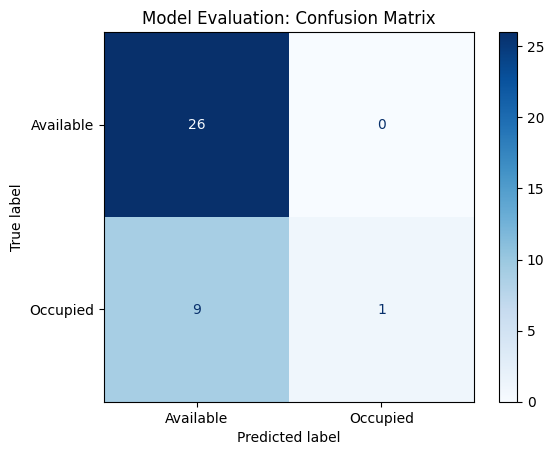

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the matrix values
cm = confusion_matrix(y_test, y_pred)

# Plot the matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_status.classes_)
disp.plot(cmap='Blues')

plt.title("Model Evaluation: Confusion Matrix")
plt.show()
